# 01 — Dataset Exploration (UTKFace)

This notebook explores UTKFace metadata and prototypes an in-notebook data loader for age and gender tasks.

## Alignment
- **Methodology**: supervised multi-task learning (age regression + gender classification)
- **Implementation checklist**: data loading, preprocessing validation, metadata exploration
- **Objectives**: build an end-to-end facial analysis pipeline from raw images to model-ready inputs

## Decisions used in this notebook
- Merge **all** UTKFace subfolders under `dataset/raw/UTKFace`
- Parse filenames with expected prefix pattern `age_gender_XXX`
- Skip malformed filenames and save an invalid-file report
- Use Adience age bins for split-feasibility diagnostics
- Save metadata artifact + invalid report to `dataset/processed`

In [1]:
# Bootstrap dependencies for this notebook kernel (safe to re-run)
%pip install -q numpy pandas pillow matplotlib pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import json
import random
import re
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "dataset").exists() and (candidate / "docs").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
RAW_ROOT = PROJECT_ROOT / "dataset" / "raw" / "UTKFace"
PROCESSED_ROOT = PROJECT_ROOT / "dataset" / "processed"

IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
AGE_GENDER_PREFIX = re.compile(r"^(?P<age>\d+)_(?P<gender>[01])(?:_(?P<rest>.+))?$")

# Adience age bins (for feasibility diagnostics only)
ADIENCE_BINS = [
    (0, 2, "0-2"),
    (4, 6, "4-6"),
    (8, 13, "8-13"),
    (15, 20, "15-20"),
    (25, 32, "25-32"),
    (38, 43, "38-43"),
    (48, 53, "48-53"),
    (60, 200, "60+"),
]

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw UTKFace root: {RAW_ROOT}")
print(f"Processed root: {PROCESSED_ROOT}")
print(f"Seed: {SEED}")

Project root: C:\Users\Mark\Projects\age-gender-cnn
Raw UTKFace root: C:\Users\Mark\Projects\age-gender-cnn\dataset\raw\UTKFace
Processed root: C:\Users\Mark\Projects\age-gender-cnn\dataset\processed
Seed: 42


In [3]:
def discover_files(raw_root: Path) -> pd.DataFrame:
    records: List[Dict[str, object]] = []
    for path in sorted(raw_root.rglob("*")):
        if path.is_dir():
            continue
        suffix = path.suffix.lower()
        is_image = suffix in IMAGE_SUFFIXES
        relative = path.relative_to(PROJECT_ROOT)
        records.append(
            {
                "path": str(path),
                "relative_path": str(relative),
                "folder": str(path.parent.relative_to(raw_root)),
                "filename": path.name,
                "suffix": suffix,
                "is_image": is_image,
                "is_zone_identifier": path.name.endswith(":Zone.Identifier"),
                "size_bytes": path.stat().st_size,
            }
        )
    return pd.DataFrame(records)

files_df = discover_files(RAW_ROOT)

print(f"Total files discovered: {len(files_df):,}")
print(f"Image candidates: {int(files_df['is_image'].sum()):,}")
print(f"Non-image files: {int((~files_df['is_image']).sum()):,}")
print(f"Zone identifier files: {int(files_df['is_zone_identifier'].sum()):,}")

files_df.head()

Total files discovered: 47,817
Image candidates: 47,814
Non-image files: 3
Zone identifier files: 0


,path,relative_path,folder,filename,suffix,is_image,is_zone_identifier,size_bytes
0,C:\Users\Mark\Projects\age-gender-cnn\dataset\...,dataset\raw\UTKFace\.DS_Store,.,.DS_Store,,False,False,223236
1,C:\Users\Mark\Projects\age-gender-cnn\dataset\...,dataset\raw\UTKFace\100_0_0_20170112213500903.jpg,.,100_0_0_20170112213500903.jpg,.jpg,True,False,97833
2,C:\Users\Mark\Projects\age-gender-cnn\dataset\...,dataset\raw\UTKFace\100_0_0_20170112213500903....,.,100_0_0_20170112213500903.jpg.chip.jpg,.jpg,True,False,7916
3,C:\Users\Mark\Projects\age-gender-cnn\dataset\...,dataset\raw\UTKFace\100_0_0_20170112215240346.jpg,.,100_0_0_20170112215240346.jpg,.jpg,True,False,108750
4,C:\Users\Mark\Projects\age-gender-cnn\dataset\...,dataset\raw\UTKFace\100_0_0_20170112215240346....,.,100_0_0_20170112215240346.jpg.chip.jpg,.jpg,True,False,7208


In [4]:
audit_summary = {
    "files_by_folder": files_df.groupby("folder").size().sort_values(ascending=False).head(20),
    "image_suffix_counts": files_df.loc[files_df["is_image"], "suffix"].value_counts(),
    "top_non_image_suffixes": files_df.loc[~files_df["is_image"], "suffix"].value_counts().head(10),
}

display(audit_summary["files_by_folder"].to_frame("count"))
display(audit_summary["image_suffix_counts"].to_frame("count"))
display(audit_summary["top_non_image_suffixes"].to_frame("count"))

,count
folder,
.,47817


,count
suffix,
.jpg,47814


,count
suffix,
,2
.pg,1


In [5]:
@dataclass
class ParseResult:
    age: Optional[int]
    gender: Optional[int]
    ethnicity: Optional[int]
    parse_status: str
    reason: str


def parse_filename(filename: str) -> ParseResult:
    stem = filename
    for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
        if stem.lower().endswith(ext):
            stem = stem[: -len(ext)]
            break

    match = AGE_GENDER_PREFIX.match(stem)
    if not match:
        return ParseResult(None, None, None, "invalid", "pattern_mismatch")

    tokens = stem.split("_")
    if len(tokens) < 2:
        return ParseResult(None, None, None, "invalid", "insufficient_tokens")

    try:
        age = int(tokens[0])
    except ValueError:
        return ParseResult(None, None, None, "invalid", "invalid_age")

    try:
        gender = int(tokens[1])
    except ValueError:
        return ParseResult(age, None, None, "invalid", "invalid_gender")

    ethnicity = None
    if len(tokens) >= 3 and tokens[2].isdigit():
        ethnicity = int(tokens[2])

    if age < 0 or age > 120:
        return ParseResult(age, gender, ethnicity, "invalid", "age_out_of_range")
    if gender not in (0, 1):
        return ParseResult(age, gender, ethnicity, "invalid", "gender_out_of_range")

    return ParseResult(age, gender, ethnicity, "valid", "ok")


images_df = files_df.loc[files_df["is_image"]].copy()
parsed = images_df["filename"].apply(parse_filename)
images_df["age"] = [result.age for result in parsed]
images_df["gender"] = [result.gender for result in parsed]
images_df["ethnicity"] = [result.ethnicity for result in parsed]
images_df["parse_status"] = [result.parse_status for result in parsed]
images_df["parse_reason"] = [result.reason for result in parsed]

valid_df = images_df.loc[images_df["parse_status"] == "valid"].copy()
invalid_df = images_df.loc[images_df["parse_status"] != "valid"].copy()

print(f"Valid parsed rows: {len(valid_df):,}")
print(f"Invalid parsed rows: {len(invalid_df):,}")
display(invalid_df["parse_reason"].value_counts().to_frame("count"))

Valid parsed rows: 47,812
Invalid parsed rows: 2


,count
parse_reason,
pattern_mismatch,2


In [6]:
quality_checks = {
    "age_min": int(valid_df["age"].min()) if len(valid_df) else None,
    "age_max": int(valid_df["age"].max()) if len(valid_df) else None,
    "gender_values": sorted(valid_df["gender"].dropna().unique().tolist()),
    "duplicate_paths": int(valid_df["path"].duplicated().sum()),
    "missing_age": int(valid_df["age"].isna().sum()),
    "missing_gender": int(valid_df["gender"].isna().sum()),
}

print(json.dumps(quality_checks, indent=2))

valid_df[["relative_path", "age", "gender", "ethnicity"]].head()

{
  "age_min": 1,
  "age_max": 116,
  "gender_values": [
    0.0,
    1.0
  ],
  "duplicate_paths": 0,
  "missing_age": 0,
  "missing_gender": 0
}


,relative_path,age,gender,ethnicity
1,dataset\raw\UTKFace\100_0_0_20170112213500903.jpg,100.0,0.0,0.0
2,dataset\raw\UTKFace\100_0_0_20170112213500903....,100.0,0.0,0.0
3,dataset\raw\UTKFace\100_0_0_20170112215240346.jpg,100.0,0.0,0.0
4,dataset\raw\UTKFace\100_0_0_20170112215240346....,100.0,0.0,0.0
5,dataset\raw\UTKFace\100_1_0_20170110183726390.jpg,100.0,1.0,0.0


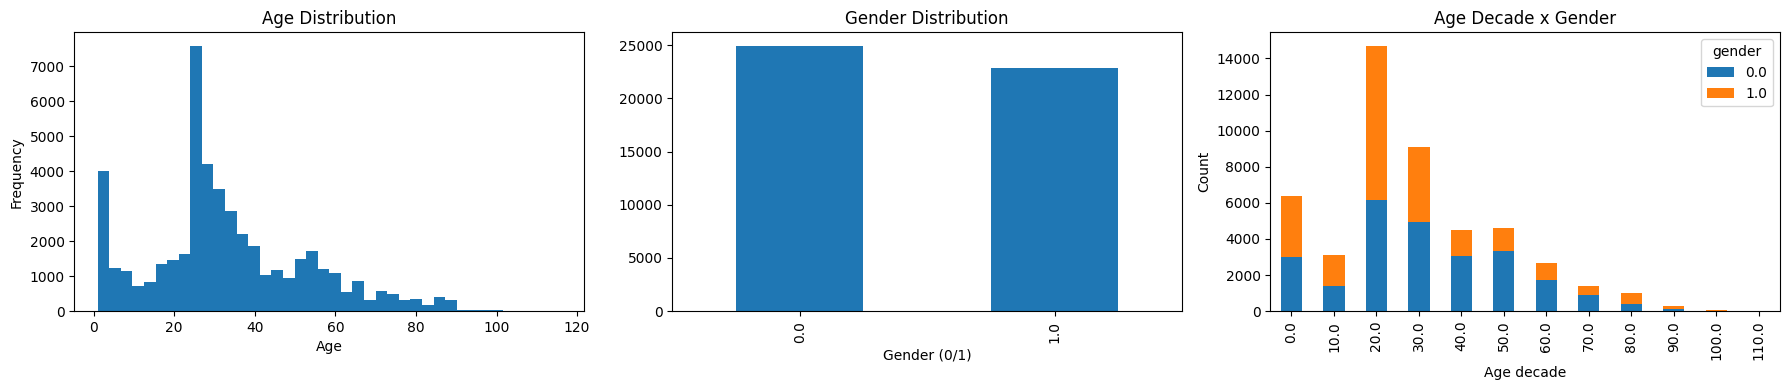

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

valid_df["age"].plot(kind="hist", bins=40, ax=axes[0], title="Age Distribution")
axes[0].set_xlabel("Age")

valid_df["gender"].value_counts().sort_index().plot(kind="bar", ax=axes[1], title="Gender Distribution")
axes[1].set_xlabel("Gender (0/1)")

(
    valid_df.assign(age_decade=(valid_df["age"] // 10) * 10)
    .groupby(["age_decade", "gender"])
    .size()
    .unstack(fill_value=0)
    .plot(kind="bar", stacked=True, ax=axes[2], title="Age Decade x Gender")
)
axes[2].set_xlabel("Age decade")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [8]:
def map_to_adience_bin(age: int) -> str:
    for low, high, label in ADIENCE_BINS:
        if low <= age <= high:
            return label
    return "other"

valid_df["adience_bin"] = valid_df["age"].apply(map_to_adience_bin)

bin_counts = valid_df["adience_bin"].value_counts().reindex([b[2] for b in ADIENCE_BINS] + ["other"], fill_value=0)
gender_bin_counts = valid_df.groupby(["adience_bin", "gender"]).size().unstack(fill_value=0)

display(bin_counts.to_frame("count"))
display(gender_bin_counts)

sparse_bins = bin_counts[bin_counts < 50]
print("Sparse bins (<50 samples):")
print(sparse_bins if len(sparse_bins) else "None")

,count
adience_bin,
0-2,3418
4-6,1226
8-13,1742
15-20,2465
25-32,13563
38-43,3347
48-53,2587
60+,5438
other,14026


gender,0.0,1.0
adience_bin,,
0-2,1840,1578
15-20,1025,1440
25-32,6317,7246
38-43,2033,1314
4-6,434,792
48-53,1756,831
60+,3127,2311
8-13,810,932
other,7630,6396


Sparse bins (<50 samples):
None


In [9]:
class UTKFaceNotebookLoader:
    def __init__(self, metadata: pd.DataFrame, image_size: Tuple[int, int] = (224, 224), normalize: bool = True):
        self.metadata = metadata.reset_index(drop=True)
        self.image_size = image_size
        self.normalize = normalize
        self.mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        self.std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    def __len__(self) -> int:
        return len(self.metadata)

    def _read_image(self, path: str) -> np.ndarray:
        with Image.open(path) as img:
            img = img.convert("RGB")
            img = img.resize(self.image_size)
            arr = np.asarray(img, dtype=np.float32) / 255.0
        if self.normalize:
            arr = (arr - self.mean) / self.std
        return arr

    def __getitem__(self, idx: int) -> Dict[str, object]:
        row = self.metadata.iloc[idx]
        image = self._read_image(row["path"])
        return {
            "image": image,
            "age": float(row["age"]),
            "gender": int(row["gender"]),
            "path": row["path"],
            "relative_path": row["relative_path"],
        }


def sample_batch(loader: UTKFaceNotebookLoader, batch_size: int = 8, seed: int = 42) -> List[Dict[str, object]]:
    rng = random.Random(seed)
    indices = rng.sample(range(len(loader)), k=min(batch_size, len(loader)))
    samples = []
    for idx in indices:
        try:
            samples.append(loader[idx])
        except Exception as exc:
            samples.append({"error": str(exc), "index": idx})
    return samples

loader = UTKFaceNotebookLoader(valid_df, image_size=(224, 224), normalize=True)
print(f"Loader size: {len(loader):,}")

Loader size: 47,812


Sampled items: 12
Successful reads: 12
Read errors: 0


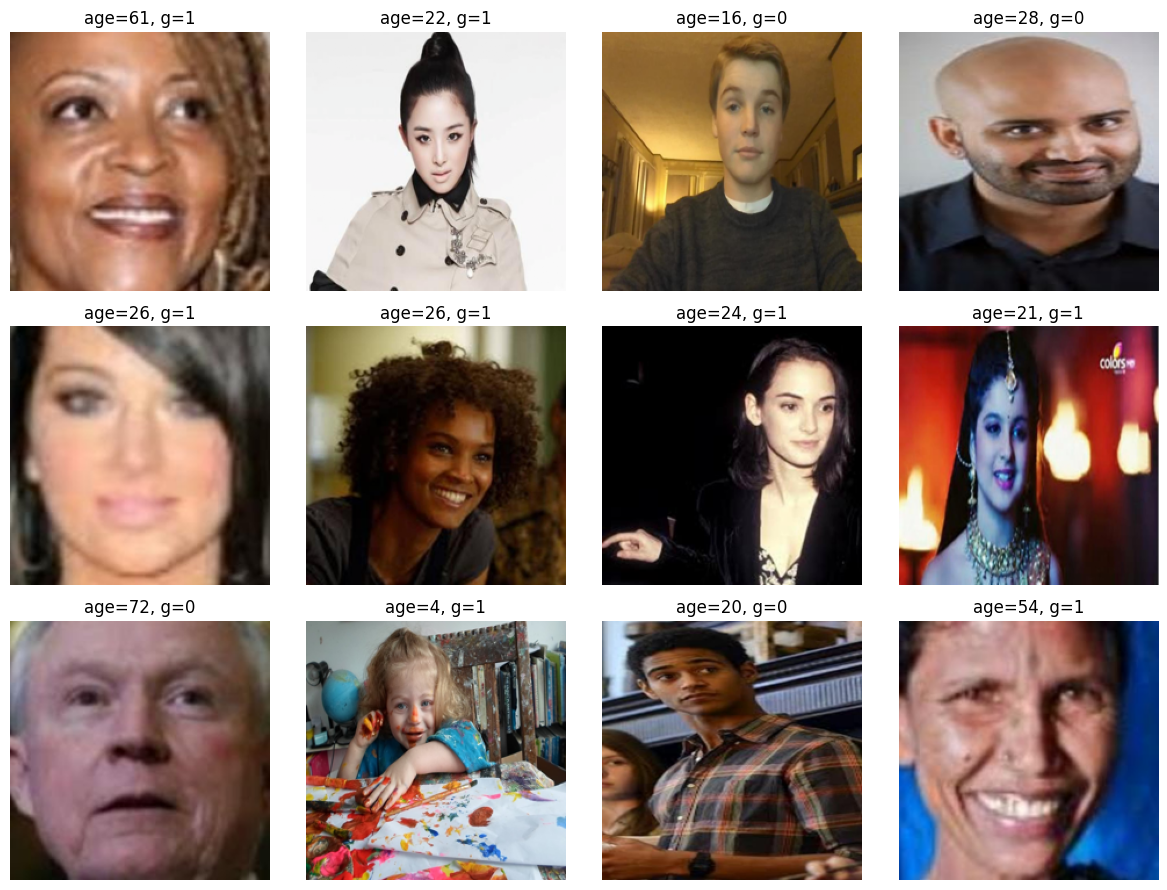

In [10]:
batch = sample_batch(loader, batch_size=12, seed=SEED)
errors = [item for item in batch if "error" in item]
valid_batch = [item for item in batch if "error" not in item]

print(f"Sampled items: {len(batch)}")
print(f"Successful reads: {len(valid_batch)}")
print(f"Read errors: {len(errors)}")
if errors:
    display(pd.DataFrame(errors).head())

if valid_batch:
    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    axes = axes.flatten()
    for ax, item in zip(axes, valid_batch):
        img = item["image"].copy()
        img = (img * loader.std + loader.mean).clip(0, 1)
        ax.imshow(img)
        ax.set_title(f"age={item['age']:.0f}, g={item['gender']}")
        ax.axis("off")
    for ax in axes[len(valid_batch):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [11]:
PROCESSED_ROOT.mkdir(parents=True, exist_ok=True)
run_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")

metadata_cols = [
    "path",
    "relative_path",
    "folder",
    "filename",
    "age",
    "gender",
    "ethnicity",
    "adience_bin",
    "size_bytes",
    "parse_status",
    "parse_reason",
]

metadata_out = valid_df[metadata_cols].copy()
invalid_out = invalid_df[
    ["path", "relative_path", "folder", "filename", "parse_status", "parse_reason", "size_bytes"]
].copy()

metadata_csv_path = PROCESSED_ROOT / f"utkface_metadata_{run_id}.csv"
invalid_csv_path = PROCESSED_ROOT / f"utkface_invalid_filenames_{run_id}.csv"
manifest_json_path = PROCESSED_ROOT / f"utkface_exploration_manifest_{run_id}.json"

metadata_out.to_csv(metadata_csv_path, index=False)
invalid_out.to_csv(invalid_csv_path, index=False)

parquet_path = None
try:
    parquet_path = PROCESSED_ROOT / f"utkface_metadata_{run_id}.parquet"
    metadata_out.to_parquet(parquet_path, index=False)
except Exception as exc:
    parquet_path = None
    print(f"Parquet export skipped: {exc}")

manifest = {
    "run_id": run_id,
    "seed": SEED,
    "raw_root": str(RAW_ROOT),
    "total_files": int(len(files_df)),
    "image_candidates": int(images_df.shape[0]),
    "valid_rows": int(metadata_out.shape[0]),
    "invalid_rows": int(invalid_out.shape[0]),
    "metadata_csv": str(metadata_csv_path),
    "metadata_parquet": str(parquet_path) if parquet_path else None,
    "invalid_report_csv": str(invalid_csv_path),
    "adience_bins": [label for _, _, label in ADIENCE_BINS],
}
manifest_json_path.write_text(json.dumps(manifest, indent=2))

print("Artifacts written:")
print(f"- {metadata_csv_path}")
print(f"- {invalid_csv_path}")
print(f"- {manifest_json_path}")
if parquet_path:
    print(f"- {parquet_path}")

Artifacts written:
- C:\Users\Mark\Projects\age-gender-cnn\dataset\processed\utkface_metadata_20260222T151110Z.csv
- C:\Users\Mark\Projects\age-gender-cnn\dataset\processed\utkface_invalid_filenames_20260222T151110Z.csv
- C:\Users\Mark\Projects\age-gender-cnn\dataset\processed\utkface_exploration_manifest_20260222T151110Z.json
- C:\Users\Mark\Projects\age-gender-cnn\dataset\processed\utkface_metadata_20260222T151110Z.parquet


## Handoff Notes

- The `metadata` artifact can be consumed by future loaders in `src/data/load_utkface.py`.
- `invalid_filenames` report documents skipped files and reasons for traceability.
- This notebook intentionally checks split feasibility with Adience bins, but does **not** create final train/val/test split manifests yet.
- Next implementation step: move validated parsing/loading logic from notebook into reusable `src/data` modules.